# REGRESIÓN

# **Descripción del conjunto de datos**  
Este conjunto de datos contiene información sobre las características de los pacientes y su influencia en el tiempo que tarda un medicamento en hacer efecto.  

Hay **11 características**, que son las siguientes:  

- **age** – edad del paciente (18-90 años)  
- **weight_kg** – peso corporal en kilogramos (50-120 kg)  
- **bmi** – índice de masa corporal calculado a partir del peso y la altura  
- **dose_mg** – dosis administrada del medicamento en miligramos (50-500 mg)  
- **administration_route** – vía de administración del medicamento (`oral`, `intravenous`, `intramuscular`, `subcutaneous`)  
- **metabolism** – velocidad del metabolismo del paciente (`slow`, `normal`, `fast`)  
- **liver_function** – estado de la función hepática (`normal`, `impaired`)  
- **alcohol_consumption** – si el paciente consume alcohol (`yes`, `no`)  
- **smoking** – si el paciente fuma tabaco (`yes`, `no`)  
- **physical_activity** – nivel de actividad física del paciente (`sedentary`, `moderate`, `active`)  
- **drug_interaction** – si el paciente toma otros fármacos que pueden interactuar (`yes`, `no`)  

Y una variable objetivo:  
- **effect_time_minutes** – tiempo (en minutos) que tarda el medicamento en hacer efecto.

# Fase 1: Recopilación de los datos

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [51]:
from google.colab import drive
drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/CURSO_MACHINE_LEARNING/CSV/drug_effect_time.csv'
df = pd.read_csv(ruta)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Fase 2: Exploración y preparación de los datos

In [52]:
# Comprobación de que los datos se han cargado correctamente
df

,age,weight_kg,bmi,dose_mg,administration_route,metabolism,liver_function,alcohol_consumption,smoking,physical_activity,drug_interaction,effect_time_minutes
0,69.0,115.0,31.35,273.0,subcutaneous,normal,impaired,yes,yes,sedentary,yes,66.48
1,32.0,72.0,21.13,362.0,intravenous,fast,normal,no,yes,sedentary,yes,11.32
2,78.0,101.0,27.66,223.0,intravenous,normal,impaired,no,no,moderate,no,30.26
3,41.0,75.0,21.23,90.0,subcutaneous,slow,normal,yes,yes,moderate,yes,72.52
4,55.0,73.0,19.96,262.0,intravenous,fast,impaired,yes,no,active,yes,69.42
...,...,...,...,...,...,...,...,...,...,...,...,...
5840,18.0,81.0,25.68,86.0,oral,fast,normal,yes,no,active,yes,86.05
5841,30.0,66.0,20.34,463.0,intramuscular,fast,impaired,yes,no,sedentary,yes,32.53
5842,23.0,85.0,25.98,198.0,oral,fast,normal,yes,yes,moderate,no,51.20
5843,44.0,52.0,21.07,423.0,intramuscular,fast,normal,no,yes,sedentary,no,3.72


In [53]:
# Informació del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5845 entries, 0 to 5844
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   5845 non-null   float64
 1   weight_kg             5845 non-null   float64
 2   bmi                   5645 non-null   float64
 3   dose_mg               5645 non-null   float64
 4   administration_route  5845 non-null   object 
 5   metabolism            5845 non-null   object 
 6   liver_function        5845 non-null   object 
 7   alcohol_consumption   5845 non-null   object 
 8   smoking               5845 non-null   object 
 9   physical_activity     5845 non-null   object 
 10  drug_interaction      5845 non-null   object 
 11  effect_time_minutes   5845 non-null   float64
dtypes: float64(5), object(7)
memory usage: 548.1+ KB


## Selección de características

De entrada no borramos ninguna

## Nulos

In [54]:
# Mostramos cuántos valores nulos hay en cada columna
print(df.isnull().sum())

age                       0
weight_kg                 0
bmi                     200
dose_mg                 200
administration_route      0
metabolism                0
liver_function            0
alcohol_consumption       0
smoking                   0
physical_activity         0
drug_interaction          0
effect_time_minutes       0
dtype: int64


In [55]:
# Eliminar valores nulos y volver a comprobar
df.dropna(inplace=True)

In [56]:
print(df.isnull().sum())

age                     0
weight_kg               0
bmi                     0
dose_mg                 0
administration_route    0
metabolism              0
liver_function          0
alcohol_consumption     0
smoking                 0
physical_activity       0
drug_interaction        0
effect_time_minutes     0
dtype: int64


## Únicos

In [57]:
# Comprobación de los valores únicos en columnas de tipo object
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

administration_route: ['subcutaneous' 'intravenous' 'intramuscular' 'oral']
metabolism: ['normal' 'fast' 'slow']
liver_function: ['impaired' 'normal']
alcohol_consumption: ['yes' 'no']
smoking: ['yes' 'no']
physical_activity: ['sedentary' 'moderate' 'active']
drug_interaction: ['yes' 'no']


## Duplicados

In [58]:
# Comprobamos cuántas filas están duplicadas
print("Filas duplicadas:", df.duplicated().sum())

Filas duplicadas: 190


In [59]:
# Eliminar duplicados manteniendo uno
df = df.drop_duplicates()

# Comprobar el número de duplicados después de la eliminación
print(f"Duplicados después de eliminar: {df.duplicated().sum()}")

Duplicados después de eliminar: 0


## Distribuciones

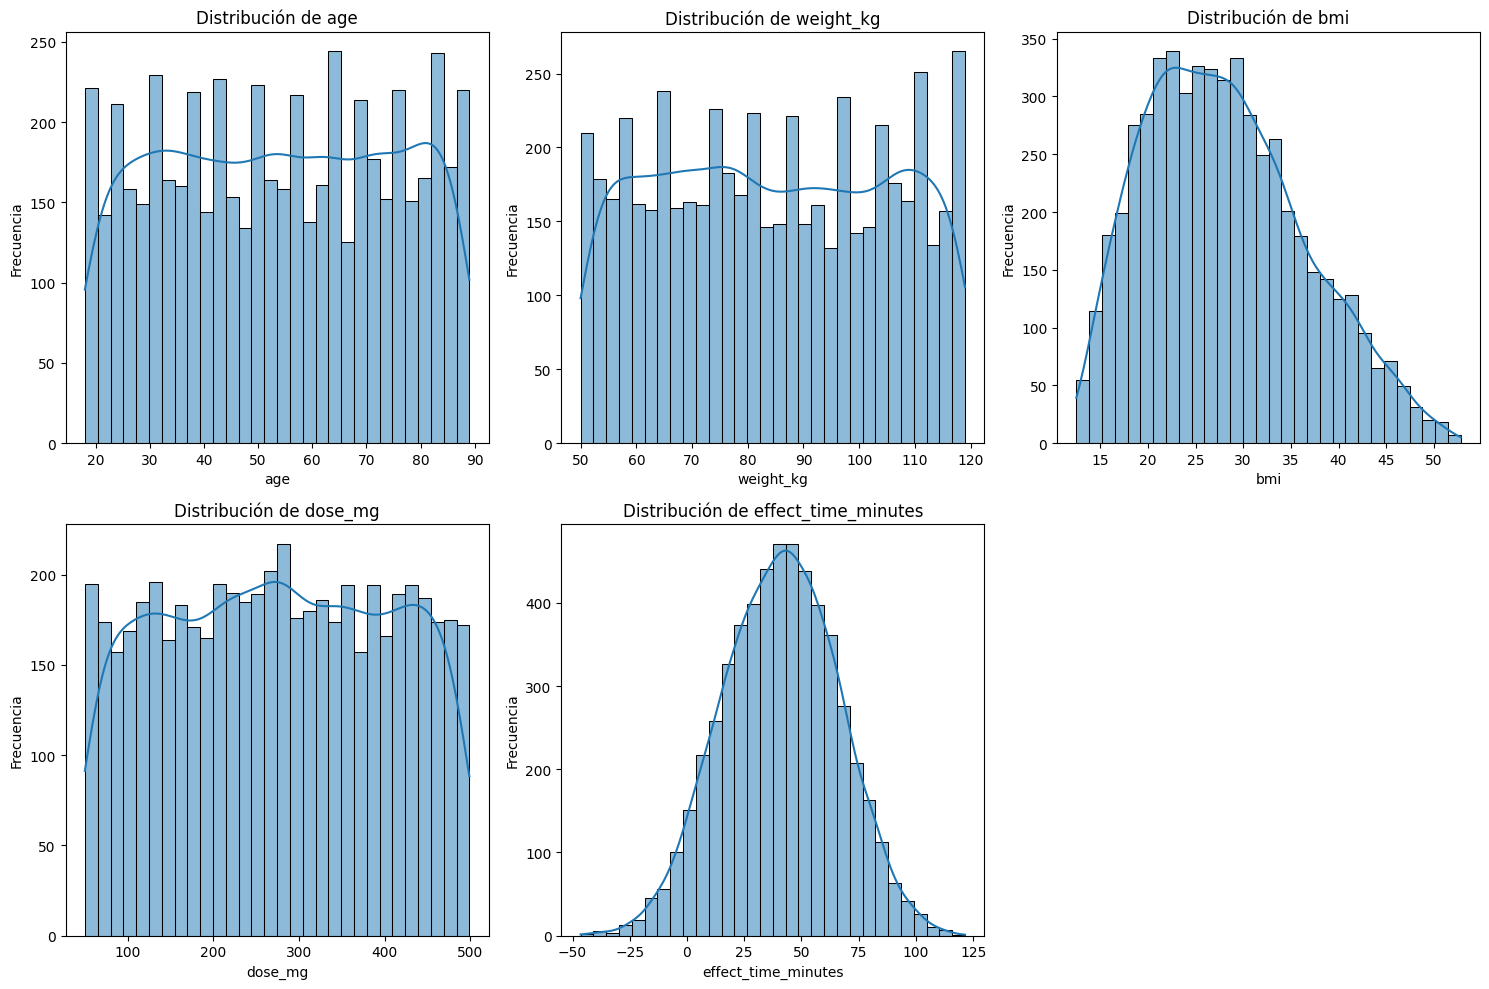

In [11]:
"""
 Las variables numéricas no siguen una distribución normal, por lo que no se recomienda usar StandardScaler.
 Usamos RobustScaler porque es más robusto frente a outliers, que están presentes en el dataset.
 Para el modelado, se probarán algoritmos que no asumen linealidad ni normalidad:
 - RandomForestRegressor y AdaBoostRegressor: robustos, manejan bien datos no lineales y variables categóricas codificadas.
 - SVR (con kernel RBF): requiere buen escalado, útil si existe alguna relación no lineal suave.
 - LinearRegression: se incluirá como referencia, pero se espera peor rendimiento dado que muchas variables no tienen relación lineal con la variable objetivo.
"""

# Seleccionar solo las columnas numéricas de tipo int o float
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Definir el número de columnas y filas para los subplots con 3 columnas
num_cols_per_row = 3
num_rows = (len(num_cols) + num_cols_per_row - 1) // num_cols_per_row  # Calcular filas necesarias

# Crear la figura con 3 columnas
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols_per_row, figsize=(15, 5 * num_rows))

# Aplanar los ejes para facilitar la iteración
axes = axes.flatten()

# Generar histogramas para cada variable numérica
for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])  # Histograma con línea KDE
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

# Ocultar ejes vacíos si el número de variables es impar
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Correlaciones con la variable objectivo

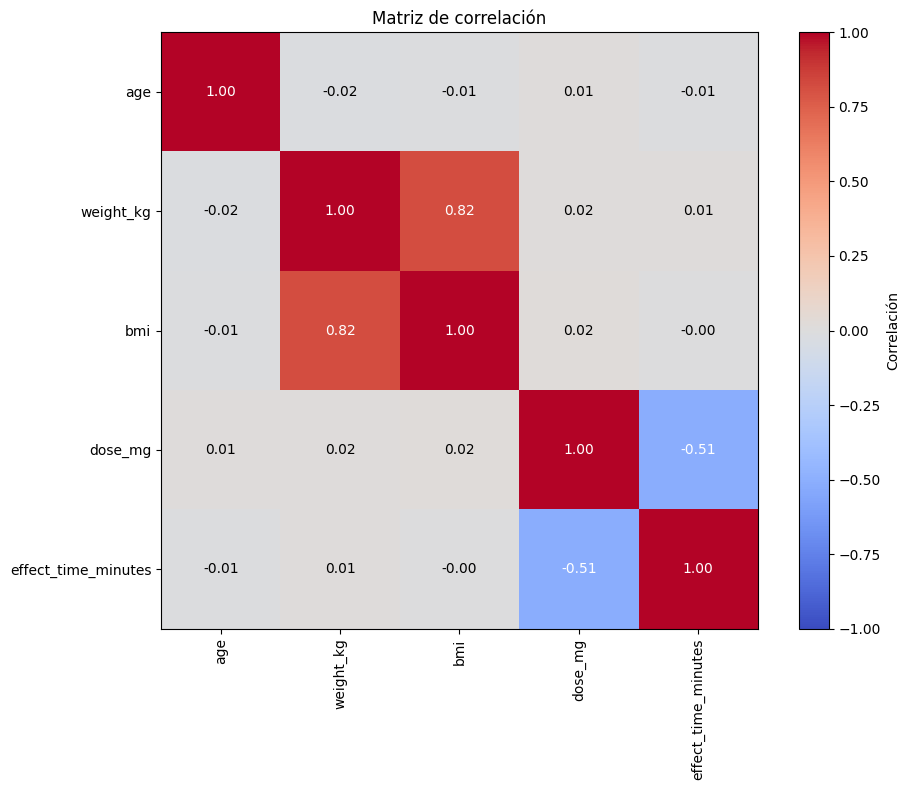

In [12]:
"""
En general, el único predictor fuerte en términos de correlación lineal directa con la variable objetivo es dose_mg.
"""

# Seleccionar solo las columnas numéricas
df_numericas = df.select_dtypes(include=["float64", "int64"])

# Calcular matriz de correlación
correlation_matrix = df_numericas.corr()

# Visualización
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="none", vmin=-1, vmax=1)
plt.colorbar(label="Correlación")

cols = df_numericas.columns
plt.xticks(range(len(cols)), cols, rotation=90)
plt.yticks(range(len(cols)), cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        value = correlation_matrix.iloc[i, j]
        color = 'white' if abs(value) > 0.5 else 'black'
        plt.text(j, i, f"{value:.2f}", ha='center', va='center', color=color, fontsize=10)

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

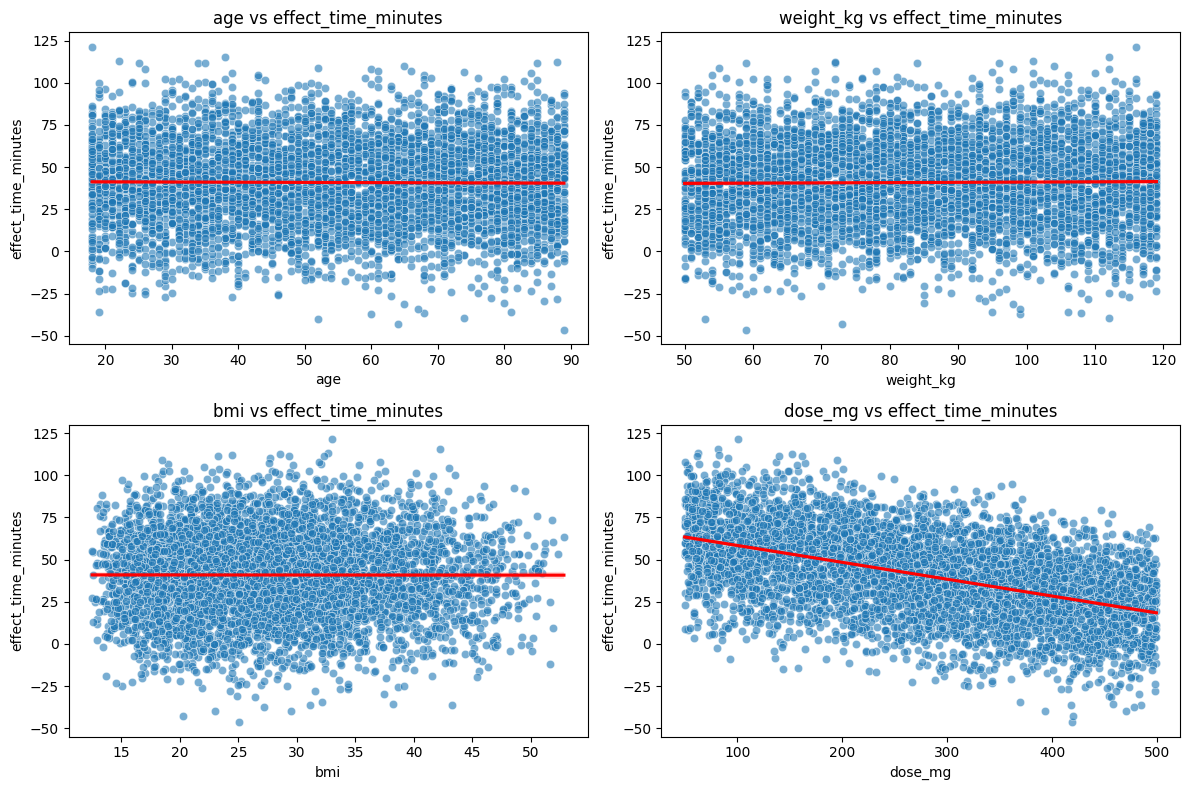

In [13]:
"""
La imagen muestra claramente que dose_mg es la única variable numérica con una relación relevante y negativa con la variable objetivo effect_time_minutes.
A medida que aumenta la dosis, el medicamento parece hacer efecto más rápido.
Las otras variables estan muy dispersas.
"""
numeric_features = ['age', 'weight_kg', 'bmi', 'dose_mg']
target = 'effect_time_minutes'

plt.figure(figsize=(12, 8))

for i, feature in enumerate(numeric_features):
    plt.subplot(2, 2, i + 1)
    sns.scatterplot(data=df, x=feature, y=target, alpha=0.6)
    sns.regplot(data=df, x=feature, y=target, scatter=False, color='red')
    plt.title(f'{feature} vs {target}')
    plt.xlabel(feature)
    plt.ylabel(target)

plt.tight_layout()
plt.show()

## Equilibrio

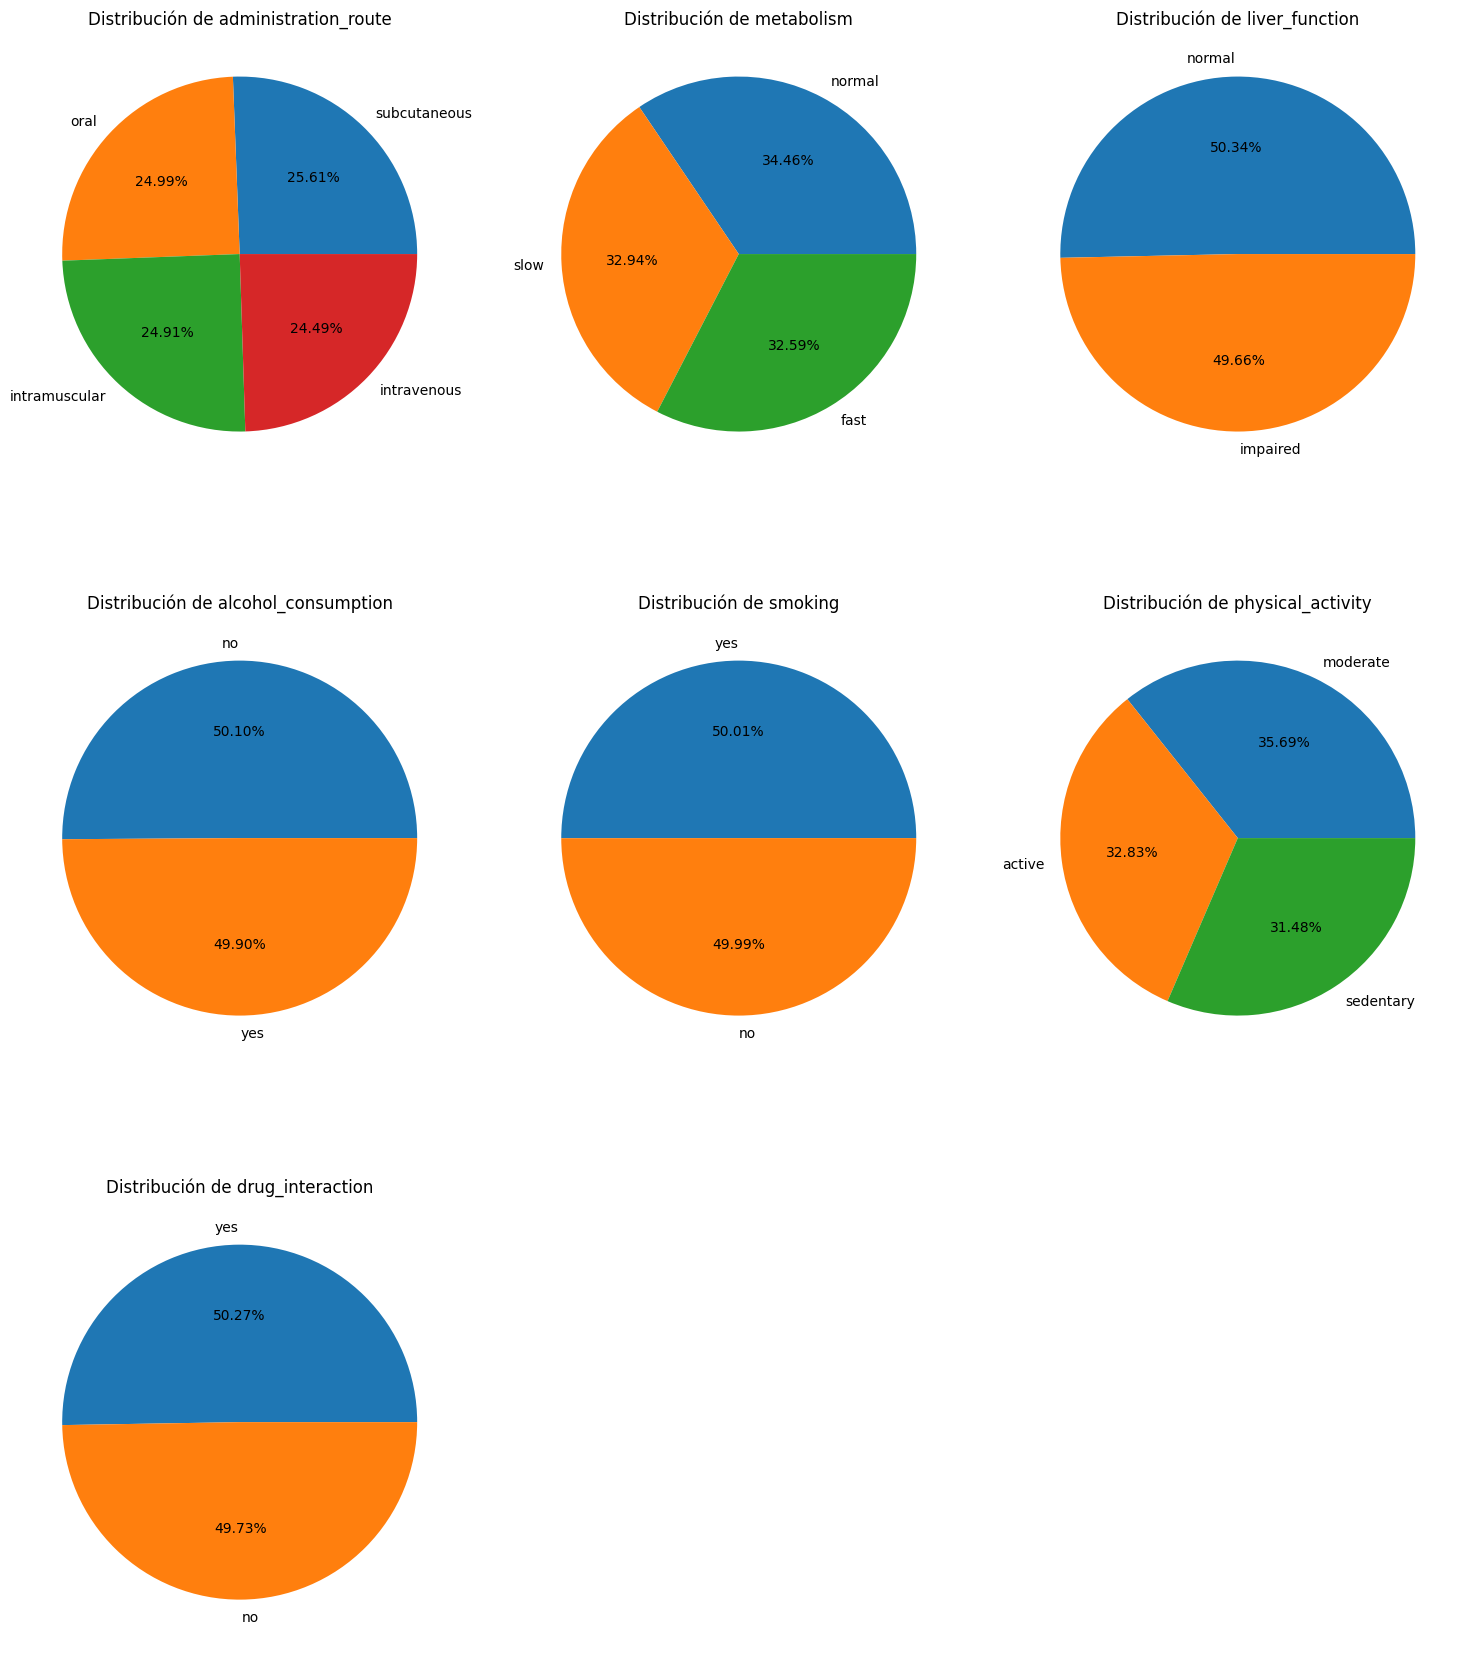

In [14]:
# Comprobamos si las variables categóricas están equilibradas

import matplotlib.pyplot as plt

# Seleccionar las columnas categóricas (tipo 'object' o 'category')
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Configurar los gráficos en 3 columnas
num_cols_per_row = 3
num_rows = (len(cat_cols) + num_cols_per_row - 1) // num_cols_per_row  # Calcular filas necesarias

# Crear la figura con 3 columnas
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols_per_row, figsize=(15, 6 * num_rows))

# Aplanar los ejes para facilitar el recorrido
axes = axes.flatten()

# Generar gráficos de sectores para cada variable categórica
for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    labels = counts.index.astype(str)

    axes[i].pie(counts, labels=labels, autopct='%.2f%%')
    axes[i].set_title(f'Distribución de {col}')

# Ocultar ejes vacíos si hay menos categorías que subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Outliers

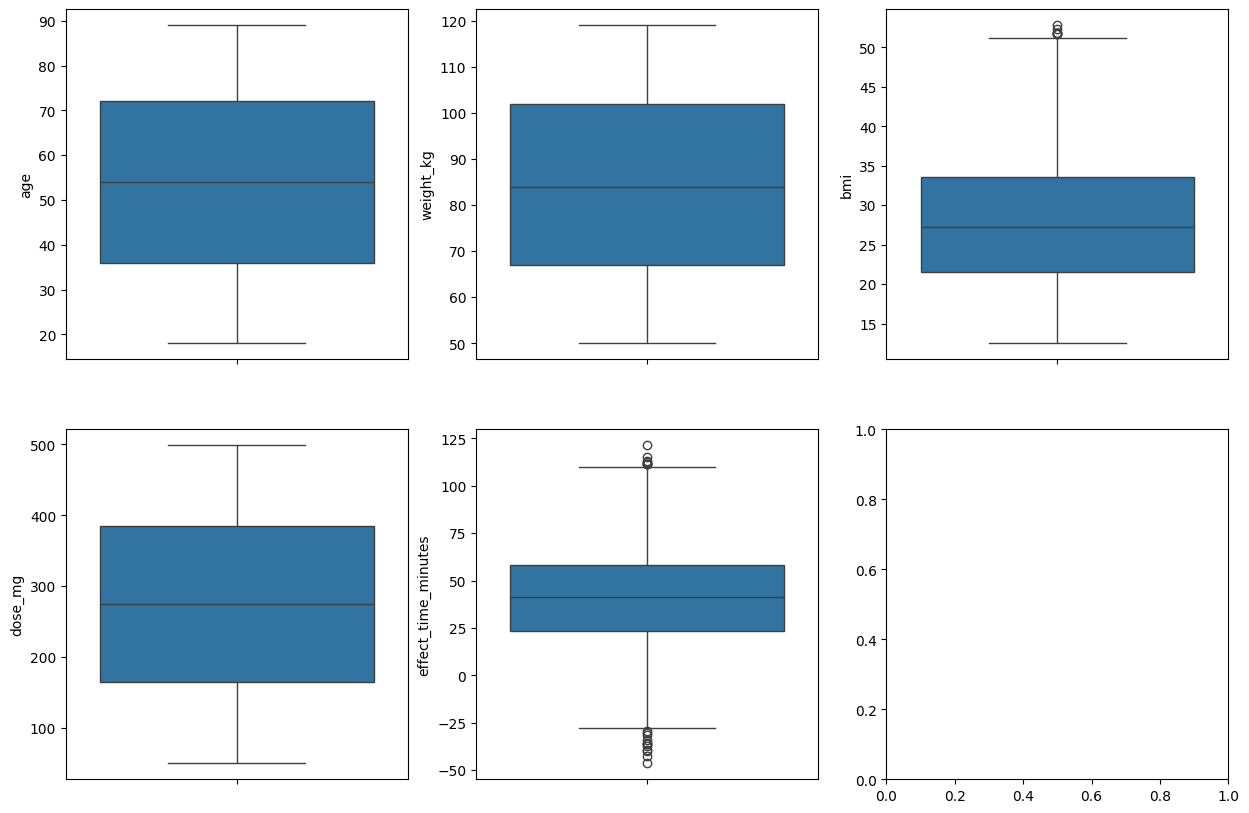

In [60]:
# Seleccionar las columnas numéricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Configurar los gráficos en 3 columnas
num_cols_per_row = 3
num_rows = (len(num_cols) + num_cols_per_row - 1) // num_cols_per_row

# Crear la figura
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols_per_row, figsize=(15, 5 * num_rows))
axes = axes.flatten()

# Generar boxplots para cada variable numérica
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title

In [61]:
# Calcular el rango intercuartílico (IQR) para cada columna numérica
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Contar el número de outliers por característica
outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))).sum()

# Mostrar el resultado
print("Número de outliers por columna:")
print(outliers)

Número de outliers por columna:
age                     0
weight_kg               0
bmi                     7
dose_mg                 0
effect_time_minutes    20
dtype: int64


In [62]:
# Filtrar las filas que NO son outliers en ninguna columna
filtro_sin_outliers = ~((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

# Aplicar el filtro al DataFrame original
df = df[filtro_sin_outliers]

In [63]:
# Calcular el rango intercuartílico (IQR) para cada columna numérica
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Contar el número de outliers por característica
outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))).sum()

# Mostrar el resultado
print("Número de outliers por columna:")
print(outliers)

Número de outliers por columna:
age                    0
weight_kg              0
bmi                    0
dose_mg                0
effect_time_minutes    0
dtype: int64


# Fase 3: División de los datos

In [64]:
# División previa de los datos del dataframe. X serán las características e y será la columna objetivo
X = df.drop('effect_time_minutes', axis=1)
y = df['effect_time_minutes']

In [65]:
# División de los datos en entrenamiento (70%) y test (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Encoders y escalado

In [66]:
from sklearn.preprocessing import MinMaxScaler

# Definir columnas categóricas y numéricas (sin incluir la variable objetivo)
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(exclude='object').columns.tolist()

# Inicializar escalador
scaler = MinMaxScaler()

# Inicializar diccionario para guardar los LabelEncoders
label_encoders = {}

# Aplicar LabelEncoder a las columnas categóricas (ajustar solo con el conjunto de entrenamiento)
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le

# Aplicar StandardScaler a las columnas numéricas
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Mostrar las primeras filas para verificar
print(X_train.head())
print(X_test.head())

           age  weight_kg       bmi   dose_mg  administration_route  \
3593  0.816901   0.478261  0.340140  0.276169                     3   
2539  0.901408   0.956522  0.456449  0.933185                     1   
4175  0.126761   0.898551  0.576376  0.939866                     1   
905   0.605634   0.376812  0.529853  0.915367                     3   
3323  0.492958   0.768116  0.463169  0.608018                     3   

      metabolism  liver_function  alcohol_consumption  smoking  \
3593           1               1                    0        0   
2539           2               1                    1        1   
4175           2               0                    0        1   
905            1               0                    1        0   
3323           2               0                    0        1   

      physical_activity  drug_interaction  
3593                  1                 0  
2539                  1                 0  
4175                  1                 0  


# Fase 4: Entrenamiento del modelo y realización de las predicciones y Fase 5: Validación del modelo (ANNs - MLP)

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers
import numpy as np
import random
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Fijar la semilla aleatoria para reproducibilidad
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)

# Definición de la red neuronal
regresor_ANNs = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(1)  # Capa de salida sin activación para regresión
])

# Compilación del modelo
regresor_ANNs.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Entrenamiento del modelo
history = regresor_ANNs.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))

# Evaluación del modelo con los datos de test
loss, mae = regresor_ANNs.evaluate(X_test, y_test)

# Predicción
predicciones_ANN = regresor_ANNs.predict(X_test)

# Cálculo de métricas
r2 = r2_score(y_test, predicciones_ANN)
mse = mean_squared_error(y_test, predicciones_ANN)
rmse = np.sqrt(mse)

print('R^2:', r2)
print('RMSE:', rmse)


Epoch 1/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 1855.7052 - mae: 36.3478 - val_loss: 544.0999 - val_mae: 19.0436
Epoch 2/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 535.5515 - mae: 18.6672 - val_loss: 433.9128 - val_mae: 16.8959
Epoch 3/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 415.2018 - mae: 16.4713 - val_loss: 353.7910 - val_mae: 15.1597
Epoch 4/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 336.1178 - mae: 14.8073 - val_loss: 289.6865 - val_mae: 13.7768
Epoch 5/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 279.4089 - mae: 13.4939 - val_loss: 240.4639 - val_mae: 12.6043
Epoch 6/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 238.8177 - mae: 12.4545 - val_loss: 205.2079 - val_mae: 11.6968
Epoch 7/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 210.7688 - mae: 11.6973 - val_loss: 180.2073 - val_mae: 10.9734
Epoch 8/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 190.9489 - mae: 11.0863 - val_loss: 164.7537 - val_mae: 10.4738
Epoch 9

#Fase 6: Optimitzación del modelo y Fase 7: Validación del nuevo modelo (ANNs - MLP)

In [23]:
!pip install -U scikeras

In [24]:
!pip install -U scikit-learn tensorflow

In [25]:
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, RMSprop
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Función con estructura fija: 64 → 128 → 1
def crear_modelo(activation='relu', optimizer='adam'):
    model = Sequential([
        Dense(64, activation=activation, input_shape=(X_train.shape[1],)),
        Dense(128, activation=activation),
        Dense(1)  # Salida sin activación para regresión
    ])
    model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])
    return model

# Envoltorio
regresor_ANNs_2 = KerasRegressor(model=crear_modelo, verbose=0)

# Rejilla de hiperparámetros
param_grid = {
    'epochs': [20, 40],
    'batch_size': [16, 32],
    'model__activation': ['relu', 'tanh'],
    'model__optimizer': ['adam', 'rmsprop']
}

# Grid search
grid = GridSearchCV(estimator=regresor_ANNs_2, param_grid=param_grid, cv=3)
grid_result = grid.fit(X_train, y_train)

# Resultados
print("Mejores parámetros:", grid_result.best_params_)
print("Mejor MAE medio:", grid_result.best_score_)

# Evaluación en test
regresor_ANNs_2 = grid.best_estimator_
predicciones = regresor_ANNs_2.predict(X_test)

r2 = r2_score(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))

print("R²:", r2)
print("RMSE:", rmse)

Mejores parámetros: {'batch_size': 16, 'epochs': 40, 'model__activation': 'relu', 'model__optimizer': 'adam'}
Mejor MAE medio: 0.8224123169264299
R²: 0.8213068433556191
RMSE: 10.298465081938897


# Fase 8: Conclusiones

# Fase 9: Pruebas

## Guardar el modelo

In [26]:
import os

ruta = '/content/drive/MyDrive/CURSO_MACHINE_LEARNING/MEJORES_MODELOS/'

os.makedirs(ruta, exist_ok=True)

# Guardar modelo directamente
regresor_ANNs.save(os.path.join(ruta, "exit_regresion.h5"))

## Cargamos el modelo

In [67]:
from tensorflow.keras.models import load_model

# Ruta donde se guardó el modelo
ruta = '/content/drive/MyDrive/CURSO_MACHINE_LEARNING/MEJORES_MODELOS/exit_regresion.h5'

# Cargar el modelo
mejor_modelo_ANNs = load_model(ruta)

## Comprobación del sobreajuste

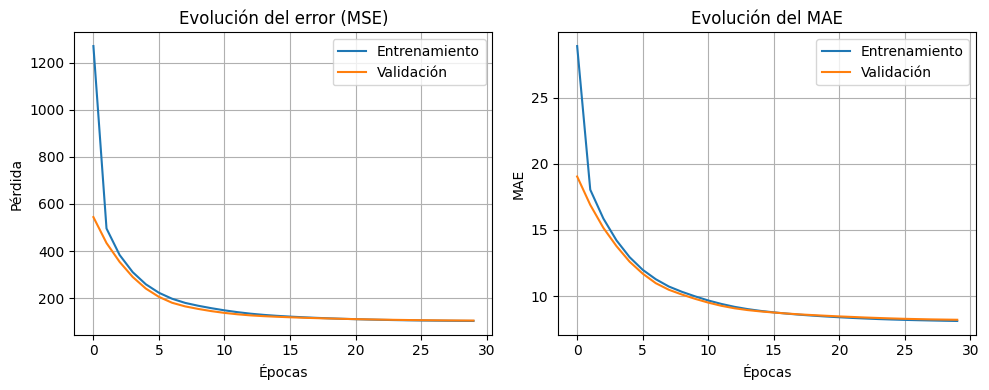

In [68]:
# En el primer gráfico, observamos la evolución del error cuadrático medio (MSE) a lo largo de las épocas.
# Se aprecia una disminución constante y paralela en las curvas de entrenamiento y validación, lo que indica
# que el modelo está aprendiendo de forma progresiva sin señales claras de sobreajuste. Ambas curvas se estabilizan hacia el final.

# En el segundo gráfico, la métrica de error absoluto medio (MAE) sigue un patrón muy similar.
# Tanto en entrenamiento como en validación, el MAE disminuye de forma paralela y sostenida,
# sin una separación significativa entre ambas curvas. Esto refuerza la idea de que el modelo generaliza correctamente.

import matplotlib.pyplot as plt

# Visualizar la evolución de la pérdida (MSE) en entrenamiento y validación
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Evolución del error (MSE)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# Visualizar la evolución del MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Entrenamiento')
plt.plot(history.history['val_mae'], label='Validación')
plt.title('Evolución del MAE')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [69]:
# Predicciones del modelo
train_preds = mejor_modelo_ANNs.predict(X_train)
test_preds = mejor_modelo_ANNs.predict(X_test)

# Métricas de rendimiento en entrenamiento y test
train_r2 = r2_score(y_train, train_preds)
test_r2 = r2_score(y_test, test_preds)

train_mse = mean_squared_error(y_train, train_preds)
test_mse = mean_squared_error(y_test, test_preds)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

print(f"R² entrenamiento: {train_r2:.4f}")
print(f"R² test: {test_r2:.4f}")
print(f"RMSE entrenamiento: {train_rmse:.4f}")
print(f"RMSE test: {test_rmse:.4f}")

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
R² entrenamiento: 0.8386
R² test: 0.8238
RMSE entrenamiento: 9.9890
RMSE test: 10.2254


## Más pruebas

In [72]:
# Hacer predicciones con el mejor modelo
predicciones = mejor_modelo_ANNs.predict(X_test).flatten()  # Asegura que sea 1D

# Mostrar los 25 primeros valores reales, predichos, diferencias y porcentaje de error
for i in range(25):
    real = y_test.values[i]
    predicho = predicciones[i]
    diferencia = real - predicho
    error_porcentual = abs(diferencia / real) * 100 if real != 0 else 0

    print(f"{i+1}: Valor real: {real:.2f} - Valor predicho: {predicho:.2f} - "
          f"Diferencia: {diferencia:.2f} - Error: {error_porcentual:.2f}%")


51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1: Valor real: 25.13 - Valor predicho: 17.25 - Diferencia: 7.88 - Error: 31.35%
2: Valor real: 59.06 - Valor predicho: 52.54 - Diferencia: 6.52 - Error: 11.04%
3: Valor real: 18.04 - Valor predicho: 27.07 - Diferencia: -9.03 - Error: 50.05%
4: Valor real: 45.61 - Valor predicho: 51.94 - Diferencia: -6.33 - Error: 13.87%
5: Valor real: 40.65 - Valor predicho: 26.79 - Diferencia: 13.86 - Error: 34.11%
6: Valor real: 5.64 - Valor predicho: 14.04 - Diferencia: -8.40 - Error: 149.02%
7: Valor real: 66.17 - Valor predicho: 57.23 - Diferencia: 8.94 - Error: 13.50%
8: Valor real: 52.73 - Valor predicho: 71.93 - Diferencia: -19.20 - Error: 36.41%
9: Valor real: 69.26 - Valor predicho: 64.84 - Diferencia: 4.42 - Error: 6.38%
10: Valor real: 81.72 - Valor predicho: 77.83 - Diferencia: 3.89 - Error: 4.76%
11: Valor real: 40.94 - Valor predicho: 46.73 - Diferencia: -5.79 - Error: 14.13%
12: Valor real: 67.07 - Valor predicho: 66.30 - Diferencia: 0.77 - Error: 

### Criterios para valorar el error porcentual en regresión

| Nivel        | Rango de error      | Interpretación                                                                 |
|--------------|---------------------|---------------------------------------------------------------------------------|
| ✔️ Bueno     | Menos del 10%        | Predicción muy ajustada. El modelo funciona de forma óptima.                   |
| ➖ Aceptable | Entre 10% y 30%      | El modelo capta la tendencia, aunque con cierta imprecisión.                   |
| ❌ Malo      | Más del 30%          | Error elevado. El modelo no generaliza bien o hay casos atípicos o ruido.      |

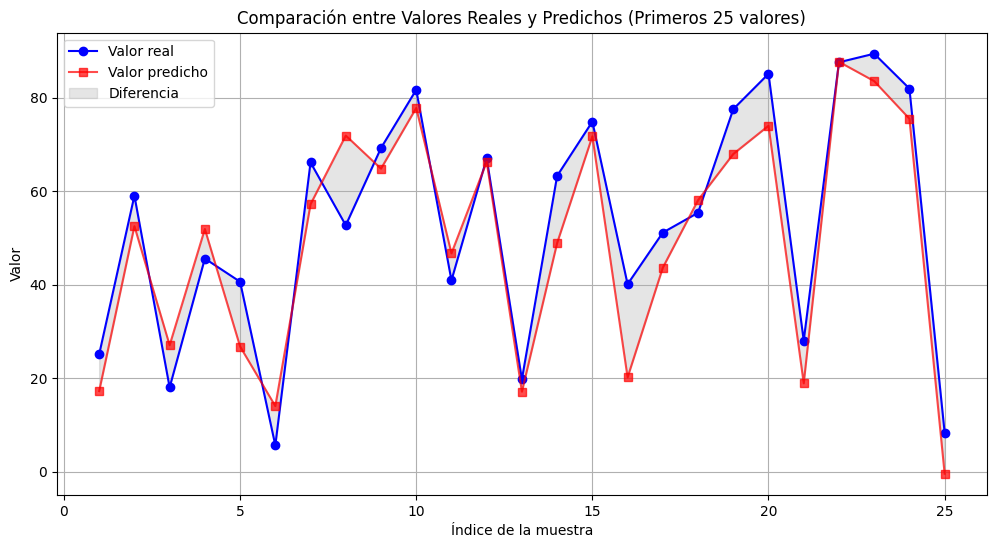

In [73]:
# Tomamos los primeros 25 valores
valores_reales_25 = y_test.values[:25]
valores_predichos_25 = predicciones[:25]
indices = list(range(1, 26))

# Crear el gráfico
plt.figure(figsize=(12, 6))
plt.plot(indices, valores_reales_25, marker='o', linestyle='-', label='Valor real', color='blue')
plt.plot(indices, valores_predichos_25, marker='s', linestyle='-', label='Valor predicho', color='red', alpha=0.7)
plt.fill_between(indices, valores_reales_25, valores_predichos_25, color='gray', alpha=0.2, label='Diferencia')

# Configuración del gráfico
plt.xlabel("Índice de la muestra")
plt.ylabel("Valor")
plt.title("Comparación entre Valores Reales y Predichos (Primeros 25 valores)")
plt.legend()
plt.grid(True)

# Mostrar el gráfico
plt.show()

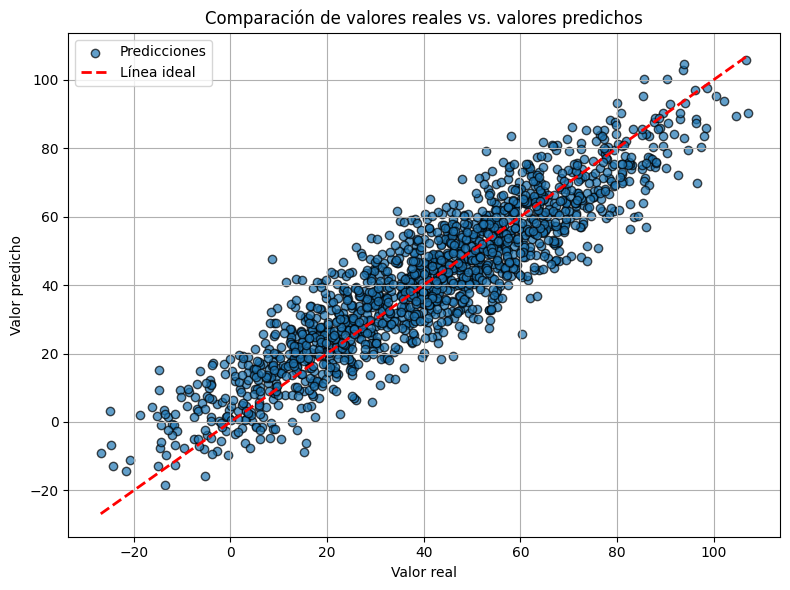

In [74]:
"""se detectan algunos errores más marcados en los extremos del rango"""
# Crear el gráfico de dispersión para todo el conjunto de test
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predicciones, alpha=0.7, edgecolors='k', label="Predicciones")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Línea ideal")

# Configuración del gráfico
plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.title('Comparación de valores reales vs. valores predichos')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Mostrar el gráfico
plt.show()


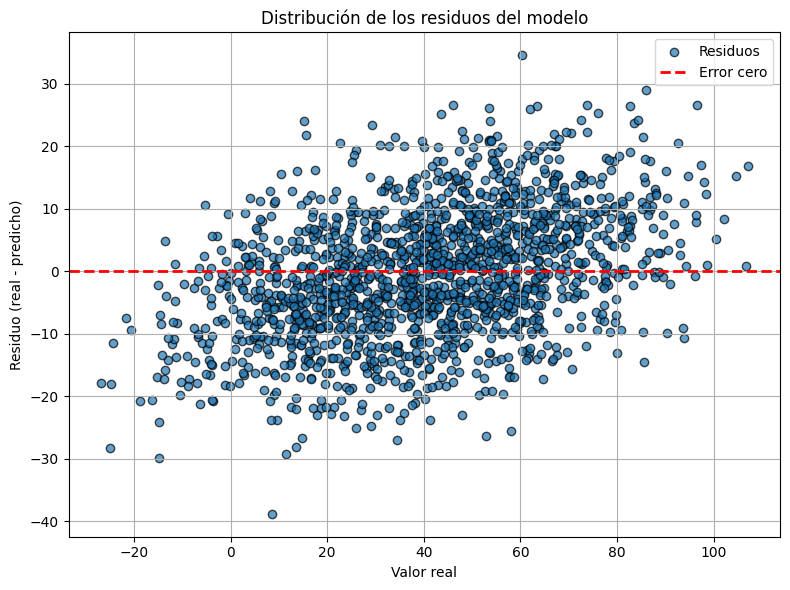

In [75]:
"""Sin embargo, se aprecia una ligera expansión de la dispersión de los residuos en los extremos
del eje X (valores reales bajos y altos), lo que podría indicar cierta heterocedasticidad.
Aun así, el comportamiento general es aceptable y no hay signos evidentes de sobreajuste.
Este gráfico, combinado con las métricas globales (R² y RMSE) y la curva de aprendizaje,
confirma que el modelo generaliza bien."""

# Calcular los residuos (errores entre valores reales y predichos)
residuos = y_test.values - predicciones.flatten()

# Crear el gráfico de residuos
plt.figure(figsize=(8, 6))
plt.scatter(y_test, residuos, alpha=0.7, edgecolors='k', label="Residuos")
plt.axhline(y=0, color='red', linestyle='--', lw=2, label="Error cero")

# Configuración del gráfico
plt.xlabel('Valor real')
plt.ylabel('Residuo (real - predicho)')
plt.title('Distribución de los residuos del modelo')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Mostrar el gráfico
plt.show()


## Nuevas predicciones

In [76]:
# Predicción del dataset 66,48
# Ejemplo de nueva observación (sin la variable objetivo)
nueva_observacion = pd.DataFrame({
    'age': [69],
    'weight_kg': [115],
    'bmi': [31.35],
    'dose_mg': [273],
    'administration_route': ['subcutaneous'],
    'metabolism': ['normal'],
    'liver_function': ['impaired'],
    'alcohol_consumption': ['yes'],
    'smoking': ['yes'],
    'physical_activity': ['sedentary'],
    'drug_interaction': ['yes']
})

# Codificar las columnas categóricas usando los LabelEncoders previamente entrenados
for col in cat_cols:
    nueva_observacion[col] = label_encoders[col].transform(nueva_observacion[col])

# Escalar las columnas numéricas usando el mismo MinMaxScaler
nueva_observacion[num_cols] = scaler.transform(nueva_observacion[num_cols])

# Realizar la predicción con el modelo mejor_modelo_ANNs
prediccion_nueva = mejor_modelo_ANNs.predict(nueva_observacion)

# Mostrar la predicción
print(f"Predicción (valor objetivo) para la nueva observación: {prediccion_nueva[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Predicción (valor objetivo) para la nueva observación: 59.26


In [77]:
# Predicción del dataset 11,32
# Ejemplo de nueva observación (sin la variable objetivo)
nueva_observacion = pd.DataFrame({
    'age': [32],
    'weight_kg': [72],
    'bmi': [21.13],
    'dose_mg': [273],
    'administration_route': ['intravenous'],
    'metabolism': ['fast'],
    'liver_function': ['normal'],
    'alcohol_consumption': ['no'],
    'smoking': ['yes'],
    'physical_activity': ['sedentary'],
    'drug_interaction': ['yes']
})

# Codificar variables categóricas con los LabelEncoders entrenados
for col in cat_cols:
    nueva_observacion[col] = label_encoders[col].transform(nueva_observacion[col])

# Escalar variables numéricas con el MinMaxScaler entrenado
nueva_observacion[num_cols] = scaler.transform(nueva_observacion[num_cols])

# Predecir con el modelo mejor_modelo_ANNs
prediccion_nueva = mejor_modelo_ANNs.predict(nueva_observacion)

# Mostrar el resultado
print(f"Predicción (valor objetivo) para la nueva observación: {prediccion_nueva[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicción (valor objetivo) para la nueva observación: 7.87


# Predicciones automáticas

In [78]:
# Número de observaciones a generar
n = 10

# Lista para guardar resultados
resultados = []

for _ in range(n):
    # Generar variables numéricas dentro de su rango real
    nueva_obs = {col: [np.random.uniform(df[col].min(), df[col].max())] for col in num_cols}

    # Añadir variables categóricas aleatorias
    for col in cat_cols:
        nueva_obs[col] = [random.choice(df[col].unique())]

    # Crear DataFrame
    nueva_obs_df = pd.DataFrame(nueva_obs)

    # Guardar la observación original antes de transformar
    observacion_original = nueva_obs_df.copy()

    # Codificar categóricas
    for col in cat_cols:
        nueva_obs_df[col] = label_encoders[col].transform(nueva_obs_df[col])

    # Escalar numéricas
    nueva_obs_df[num_cols] = scaler.transform(nueva_obs_df[num_cols])

    # Predecir
    prediccion = mejor_modelo_ANNs.predict(nueva_obs_df)[0][0]

    # Añadir la predicción a la observación original
    observacion_original['prediccion'] = prediccion

    # Guardar
    resultados.append(observacion_original)

    # Mostrar
    print("\nObservación generada:")
    print(observacion_original.to_string(index=False))
    print(f"Predicción del valor objetivo: {prediccion:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

Observación generada:
      age  weight_kg       bmi   dose_mg administration_route metabolism liver_function alcohol_consumption smoking physical_activity drug_interaction  prediccion
79.280343  93.007571 25.309063 78.537699         subcutaneous     normal         normal                 yes      no          moderate               no   57.157352
Predicción del valor objetivo: 57.16
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

Observación generada:
      age  weight_kg       bmi    dose_mg administration_route metabolism liver_function alcohol_consumption smoking physical_activity drug_interaction  prediccion
40.079745  72.437649 40.743055 336.263305        intramuscular       fast         normal                 yes     yes          moderate              yes   29.911554
Predicción del valor objetivo: 29.91
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

Observación generada:
      age  weight_kg       bmi    dose_mg administration_route metabolism liver_function 

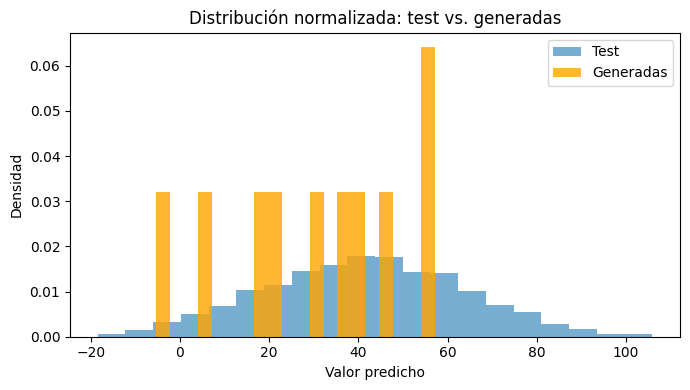

In [82]:
plt.figure(figsize=(7, 4))
plt.hist(predicciones, bins=20, alpha=0.6, label='Test', density=True)
plt.hist(predicciones_generadas, bins=20, alpha=0.8, label='Generadas', color='orange', density=True)
plt.xlabel('Valor predicho')
plt.ylabel('Densidad')
plt.title('Distribución normalizada: test vs. generadas')
plt.legend()
plt.tight_layout()
plt.show()

In [84]:
print("Media test:", np.mean(predicciones), " - Desviación:", np.std(predicciones))
print("Media generadas:", np.mean(predicciones_generadas), " - Desviación:", np.std(predicciones_generadas))

Media test: 41.14403  - Desviación: 22.202171
Media generadas: 30.66483  - Desviación: 19.965944
